In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('train.csv', encoding='latin-1')

print("✅ Data loaded successfully!")
print(f"Total records: {len(df):,}")
print(f"Columns: {list(df.columns)}")



✅ Data loaded successfully!
Total records: 9,800
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [2]:
# Clean data
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

print("✅ Data cleaned!")
print(f"Date Range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")

✅ Data cleaned!
Date Range: 2015-01-03 to 2018-12-30
Total Sales: $2,261,536.78


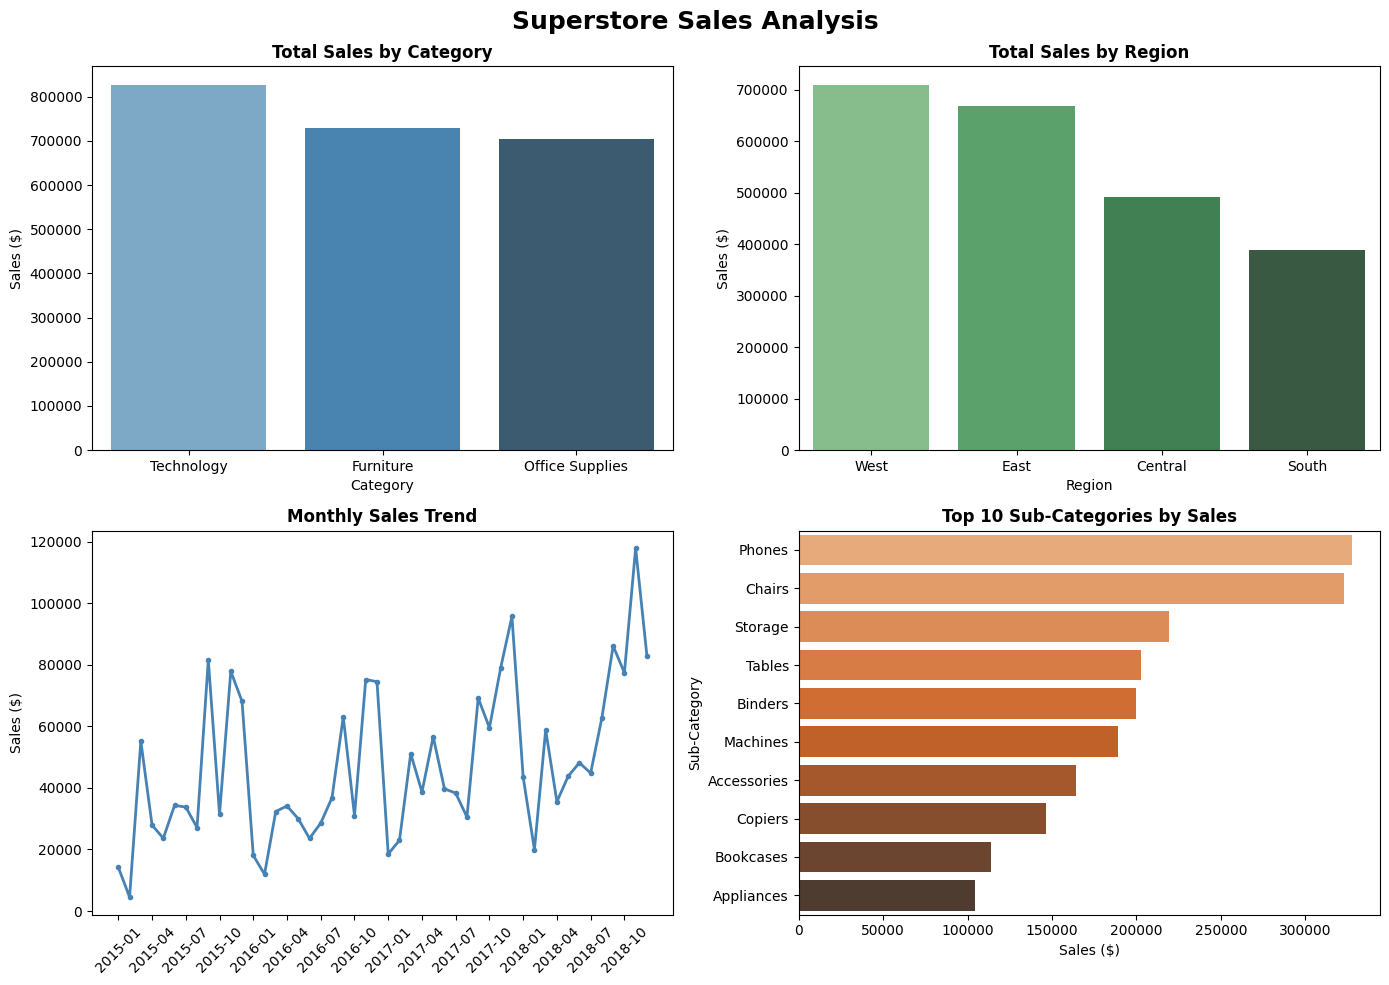

✅ Charts created and saved!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Analysis', fontsize=18, fontweight='bold')

# Chart 1: Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(data=cat_sales, x='Category', y='Sales', hue='Category', legend=False, palette='Blues_d', ax=axes[0,0])
axes[0,0].set_title('Total Sales by Category', fontweight='bold')
axes[0,0].set_ylabel('Sales ($)')

# Chart 2: Sales by Region
reg_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(data=reg_sales, x='Region', y='Sales', hue='Region', legend=False, palette='Greens_d', ax=axes[0,1])
axes[0,1].set_title('Total Sales by Region', fontweight='bold')
axes[0,1].set_ylabel('Sales ($)')

# Chart 3: Monthly Sales Trend
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)
axes[1,0].plot(monthly['Month'], monthly['Sales'], color='steelblue', linewidth=2, marker='o', markersize=3)
axes[1,0].set_title('Monthly Sales Trend', fontweight='bold')
axes[1,0].set_ylabel('Sales ($)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_xticks(axes[1,0].get_xticks()[::3])

# Chart 4: Top 10 Sub-Categories
top_sub = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).reset_index()
sns.barplot(data=top_sub, x='Sales', y='Sub-Category', hue='Sub-Category', legend=False, palette='Oranges_d', ax=axes[1,1])
axes[1,1].set_title('Top 10 Sub-Categories by Sales', fontweight='bold')
axes[1,1].set_xlabel('Sales ($)')

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts created and saved!")